# 01 — Análise Exploratória de Dados

**Problema:** prever se um solicitante de cartão de crédito tende a ser **bom** ou **mau pagador**,
a partir dos dados cadastrais e do histórico de crédito.

Este notebook descreve as duas tabelas da base, mostra como as variáveis se distribuem, procura
correlações e outliers e mede o balanceamento das classes. Cada gráfico tem sua interpretação logo
abaixo. A síntese no final é o ponto de partida do storytelling da apresentação.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

sys.path.insert(0, str(Path("..").resolve()))
from src import config
assert config.RANDOM_STATE == RANDOM_STATE

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", palette="deep")
config.FIGURES.mkdir(parents=True, exist_ok=True)

In [2]:
from src.data import load_application, load_credit

application = load_application()
credit = load_credit()
print("application_record:", application.shape)
print("credit_record:     ", credit.shape)

application_record: (438557, 18)
credit_record:      (1048575, 3)


## 1. Visão geral

A base tem duas tabelas ligadas pela coluna `ID`:

- **`application_record.csv`**: uma linha por solicitante, com os dados cadastrais.
- **`credit_record.csv`**: uma linha por cliente **e por mês**, com o status de pagamento naquele mês.

In [3]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,"427,500.0000",Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0000
1,5008805,M,Y,Y,0,"427,500.0000",Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0000
2,5008806,M,Y,Y,0,"112,500.0000",Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0000
3,5008808,F,N,Y,0,"270,000.0000",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0000
4,5008809,F,N,Y,0,"270,000.0000",Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0000


In [4]:
application.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

In [5]:
application.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,"438,557.0000","6,022,176.2698","571,637.0233","5,008,804.0000","5,609,375.0000","6,047,745.0000","6,456,971.0000","7,999,952.0000"
CNT_CHILDREN,"438,557.0000",0.4274,0.7249,0.0000,0.0000,0.0000,1.0000,19.0000
AMT_INCOME_TOTAL,"438,557.0000","187,524.2860","110,086.8531","26,100.0000","121,500.0000","160,780.5000","225,000.0000","6,750,000.0000"
DAYS_BIRTH,"438,557.0000","-15,997.9046","4,185.0300","-25,201.0000","-19,483.0000","-15,630.0000","-12,514.0000","-7,489.0000"
DAYS_EMPLOYED,"438,557.0000","60,563.6753","138,767.7996","-17,531.0000","-3,103.0000","-1,467.0000",-371.0000,"365,243.0000"
FLAG_MOBIL,"438,557.0000",1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
FLAG_WORK_PHONE,"438,557.0000",0.2061,0.4045,0.0000,0.0000,0.0000,0.0000,1.0000
FLAG_PHONE,"438,557.0000",0.2878,0.4527,0.0000,0.0000,0.0000,1.0000,1.0000
FLAG_EMAIL,"438,557.0000",0.1082,0.3106,0.0000,0.0000,0.0000,0.0000,1.0000
CNT_FAM_MEMBERS,"438,557.0000",2.1945,0.8972,1.0000,2.0000,2.0000,3.0000,20.0000


In [6]:
print("IDs únicos no cadastro:", application["ID"].nunique(), "de", len(application), "linhas")
print("IDs repetidos no cadastro:", application["ID"].duplicated().sum())
print("Colunas com um único valor:", [c for c in application if application[c].nunique() == 1])

perfis = application.drop_duplicates("ID").drop(columns="ID").drop_duplicates()
print("Perfis cadastrais distintos (todas as colunas iguais, ignorando o ID):", len(perfis))

IDs únicos no cadastro: 438510 de 438557 linhas
IDs repetidos no cadastro: 47


Colunas com um único valor: ['FLAG_MOBIL']


Perfis cadastrais distintos (todas as colunas iguais, ignorando o ID): 90085


### Dicionário de variáveis — `application_record.csv`

| Variável | Tipo | Descrição |
|---|---|---|
| `ID` | inteiro | identificador do cliente (chave de ligação com o histórico) |
| `CODE_GENDER` | categórica | gênero (F / M) |
| `FLAG_OWN_CAR` | categórica | possui carro (Y / N) |
| `FLAG_OWN_REALTY` | categórica | possui imóvel (Y / N) |
| `CNT_CHILDREN` | inteiro | número de filhos |
| `AMT_INCOME_TOTAL` | contínua | renda anual |
| `NAME_INCOME_TYPE` | categórica | tipo de renda (assalariado, servidor, aposentado, empresário, estudante) |
| `NAME_EDUCATION_TYPE` | categórica | escolaridade |
| `NAME_FAMILY_STATUS` | categórica | estado civil |
| `NAME_HOUSING_TYPE` | categórica | tipo de moradia |
| `DAYS_BIRTH` | inteiro | idade em dias, contada para trás a partir da solicitação (negativo) |
| `DAYS_EMPLOYED` | inteiro | tempo de emprego em dias (negativo); **365243 = sem vínculo** |
| `FLAG_MOBIL` | binária | possui celular |
| `FLAG_WORK_PHONE` | binária | possui telefone comercial |
| `FLAG_PHONE` | binária | possui telefone fixo |
| `FLAG_EMAIL` | binária | possui e-mail |
| `OCCUPATION_TYPE` | categórica | ocupação (com nulos) |
| `CNT_FAM_MEMBERS` | contínua | tamanho da família |

### Dicionário de variáveis — `credit_record.csv`

| Variável | Tipo | Descrição |
|---|---|---|
| `ID` | inteiro | identificador do cliente |
| `MONTHS_BALANCE` | inteiro | mês de referência (0 = mês atual, -1 = mês anterior, …) |
| `STATUS` | categórica | situação no mês: `0` = 1 a 29 dias de atraso, `1` = 30 a 59, `2` = 60 a 89, `3` = 90 a 119, `4` = 120 a 149, `5` = mais de 150 dias ou prejuízo, `C` = quitado no mês, `X` = sem empréstimo no mês |

**Interpretação:**

- **Cadastro:** 438.557 linhas × 18 colunas. A única coluna com nulos é `OCCUPATION_TYPE`
  (304.354 preenchidas, ou seja, 134.203 vazias, 30,6%).
- **IDs duplicados:** 47 IDs aparecem duas vezes. O notebook 02 mostra que as duas cópias trazem
  dados diferentes (renda, idade, tempo de emprego), então não são simples linhas repetidas.
- **A mesma pessoa com vários IDs:** os 438.510 IDs correspondem a só **90.085 perfis cadastrais
  distintos**. Muitos IDs têm todas as colunas iguais, inclusive a data de nascimento em dias (veja
  as duas primeiras linhas do `head()`). É a mesma pessoa com mais de uma conta, e isso muda a
  forma de separar treino e teste (notebook 02, seção 7).
- **`FLAG_MOBIL`** vale 1 para todo mundo: é constante e não ajuda a distinguir ninguém.
- **`DAYS_EMPLOYED`** chega a **365.243**. Isso é um código da base, não um tempo real (seriam
  1.000 anos de emprego). A seção 4 investiga o caso.
- **Histórico:** 1.048.575 linhas × 3 colunas, sem nulos.

In [7]:
status = credit["STATUS"].value_counts().reindex(["C", "X", "0", "1", "2", "3", "4", "5"])
display(pd.DataFrame({"registros": status, "pct": (status / status.sum() * 100).round(2)}))

meses_por_cliente = credit.groupby("ID")["MONTHS_BALANCE"].nunique()
print("Clientes no histórico:", credit["ID"].nunique())
print("Meses de histórico por cliente:")
print(meses_por_cliente.describe().round(1).to_string())

,registros,pct
STATUS,,
C,442031,42.1600
X,209230,19.9500
0,383120,36.5400
1,11090,1.0600
2,868,0.0800
3,320,0.0300
4,223,0.0200
5,1693,0.1600


Clientes no histórico: 45985
Meses de histórico por cliente:
count   45,985.0000
mean        22.8000
std         15.5000
min          1.0000
25%         10.0000
50%         19.0000
75%         34.0000
max         61.0000


**Interpretação:** a grande maioria dos meses é "quitado" (C, 42,2%), "sem empréstimo" (X, 20,0%)
ou atraso curto de 1 a 29 dias (0, 36,5%). Atrasos de 30 a 59 dias (1) somam 1,06% dos registros, e
atrasos de **60 dias ou mais (2 a 5) somam apenas 0,29%**. O evento que define um mau pagador é
raro, e isso vai condicionar toda a modelagem.

Cada cliente tem, em média, 22,8 meses de histórico (mediana 19, mínimo 1, máximo 61). Essa
diferença de tempo de observação entre clientes volta a aparecer na seção 5 e na interpretação do
modelo.

## 2. Distribuição das variáveis

Aqui os dias negativos de `DAYS_BIRTH` e `DAYS_EMPLOYED` são convertidos em anos só para facilitar
a leitura. O código sentinela 365243 fica de fora do histograma de tempo de emprego e é tratado à
parte na seção 4.

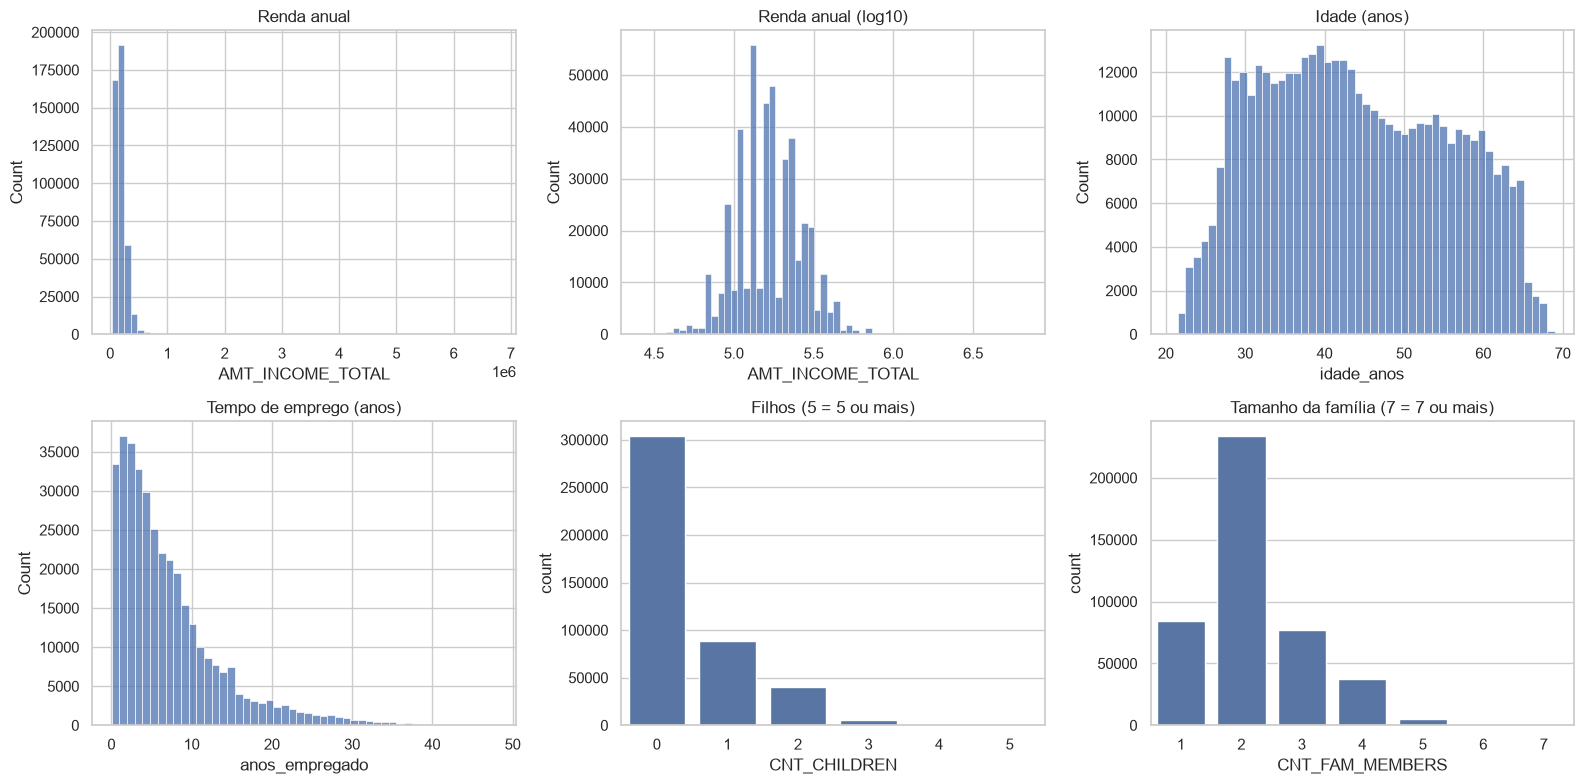

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,"438,510.0000","187,525.4157","110,089.2796","26,100.0000","121,500.0000","160,940.2500","225,000.0000","6,750,000.0000"
idade_anos,"438,510.0000",43.8002,11.4579,20.5038,34.2615,42.7926,53.3443,68.9966
anos_empregado,"363,186.0000",7.1817,6.5697,0.0329,2.5051,5.2676,9.6153,47.9973
CNT_CHILDREN,"438,510.0000",0.4274,0.7249,0.0000,0.0000,0.0000,1.0000,19.0000
CNT_FAM_MEMBERS,"438,510.0000",2.1945,0.8972,1.0000,2.0000,2.0000,3.0000,20.0000


In [8]:
vis = application.drop_duplicates("ID").copy()
vis["idade_anos"] = -vis["DAYS_BIRTH"] / 365.25
vis["anos_empregado"] = (-vis["DAYS_EMPLOYED"] / 365.25).where(vis["DAYS_EMPLOYED"] < 0)

fig, eixos = plt.subplots(2, 3, figsize=(16, 8))
sns.histplot(vis["AMT_INCOME_TOTAL"], bins=60, ax=eixos[0, 0]).set_title("Renda anual")
sns.histplot(np.log10(vis["AMT_INCOME_TOTAL"]), bins=60, ax=eixos[0, 1]).set_title("Renda anual (log10)")
sns.histplot(vis["idade_anos"], bins=50, ax=eixos[0, 2]).set_title("Idade (anos)")
sns.histplot(vis["anos_empregado"].dropna(), bins=50, ax=eixos[1, 0]).set_title("Tempo de emprego (anos)")
sns.countplot(x=vis["CNT_CHILDREN"].clip(upper=5), ax=eixos[1, 1]).set_title("Filhos (5 = 5 ou mais)")
sns.countplot(x=vis["CNT_FAM_MEMBERS"].clip(upper=7).astype(int), ax=eixos[1, 2]).set_title("Tamanho da família (7 = 7 ou mais)")
plt.tight_layout()
plt.savefig(config.FIGURES / "01_distribuicoes_numericas.png", dpi=120)
plt.show()

vis[["AMT_INCOME_TOTAL", "idade_anos", "anos_empregado", "CNT_CHILDREN", "CNT_FAM_MEMBERS"]].describe().T

**Interpretação:**

- **Renda anual:** muito assimétrica à direita. A média (187.525) é maior que a mediana (160.940),
  e o máximo chega a 6,75 milhões. Em escala logarítmica a distribuição fica próxima de uma normal,
  com picos em valores "redondos" (renda declarada arredondada).
- **Idade:** vai de 20 a 69 anos, com mediana de 42,8. É bem espalhada, sem concentração
  artificial.
- **Tempo de emprego** (sem os aposentados): mediana de 5,3 anos e cauda longa até 48 anos. A
  maioria tem pouco tempo no emprego atual.
- **Filhos e tamanho da família:** a maioria não tem filhos, e famílias de 2 pessoas são as mais
  comuns. Existem valores extremos (19 filhos, 20 membros), raros mas presentes.

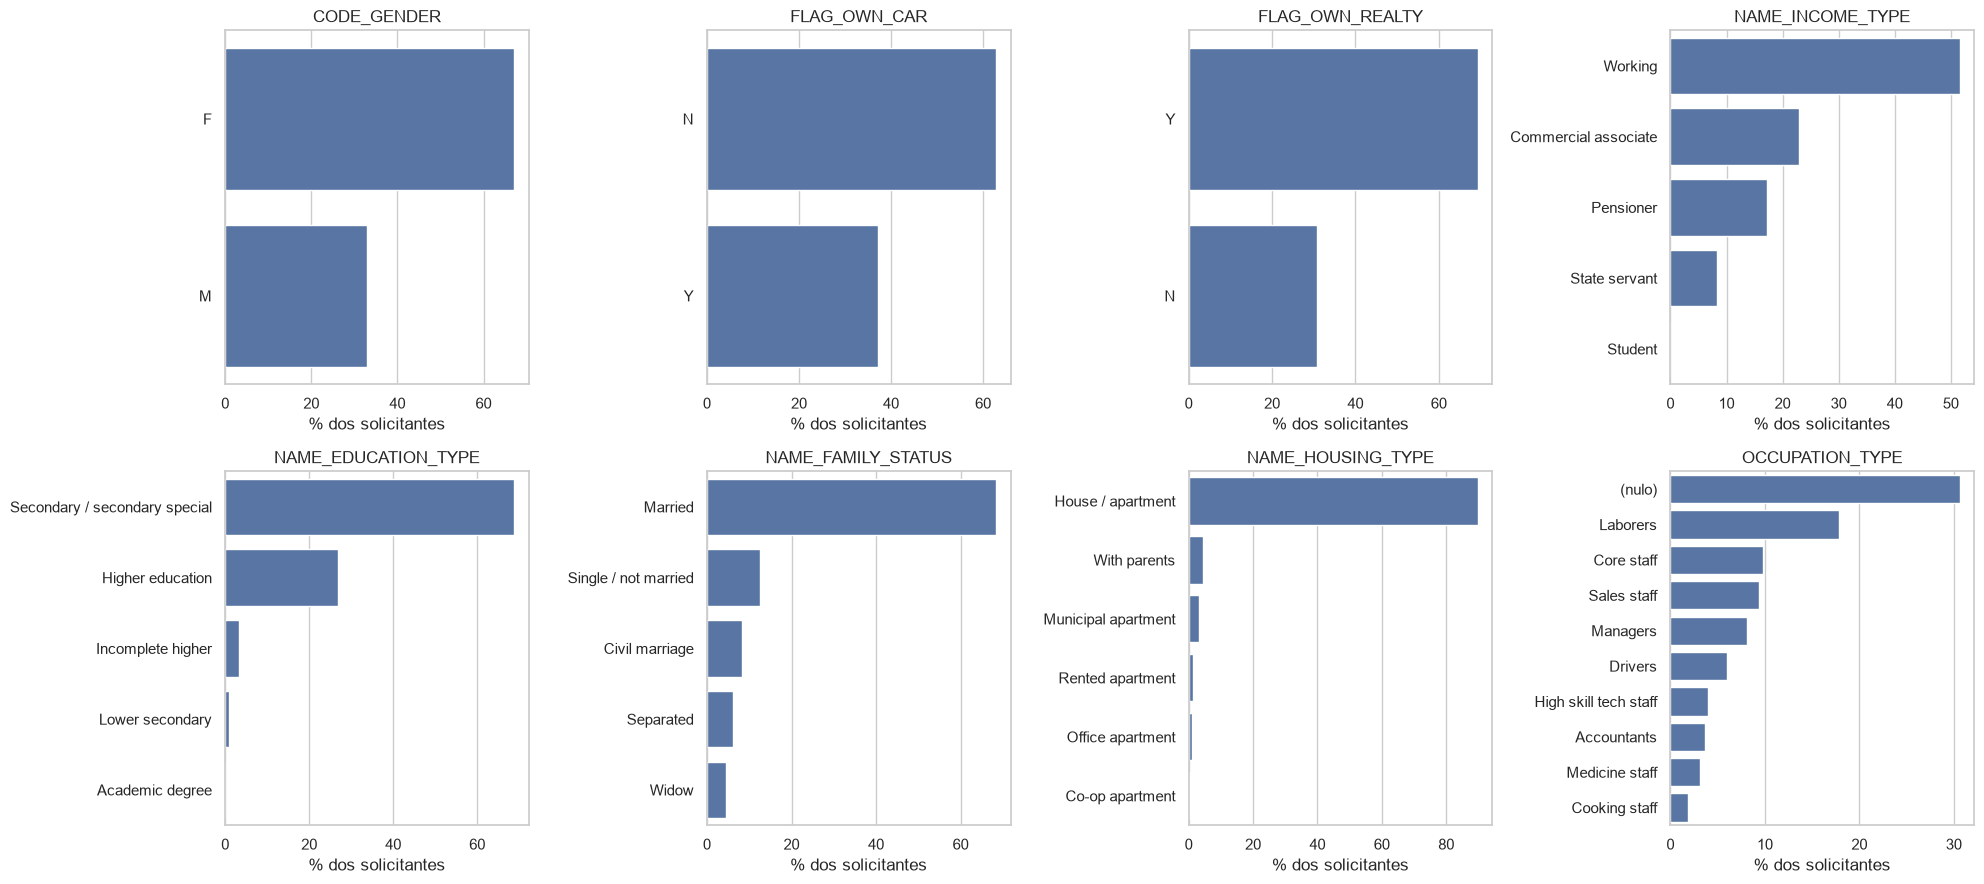

In [9]:
categoricas = ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "NAME_INCOME_TYPE",
               "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "OCCUPATION_TYPE"]
fig, eixos = plt.subplots(2, 4, figsize=(20, 9))
for eixo, col in zip(eixos.flat, categoricas):
    contagem = vis[col].fillna("(nulo)").value_counts(normalize=True).head(10) * 100
    sns.barplot(x=contagem.values, y=contagem.index, ax=eixo, color="C0")
    eixo.set_title(col)
    eixo.set_xlabel("% dos solicitantes")
    eixo.set_ylabel("")
plt.tight_layout()
plt.savefig(config.FIGURES / "01_distribuicoes_categoricas.png", dpi=120)
plt.show()

**Interpretação:**

- **Gênero:** 67,1% mulheres.
- **Patrimônio:** 62,8% não têm carro e 69,3% têm imóvel.
- **Renda:** assalariados (51,6%), empresários (23,0%), aposentados (17,2%) e servidores (8,3%).
  Estudantes são praticamente inexistentes.
- **Escolaridade e família:** 68,8% têm ensino médio, 68,4% são casados e 89,8% moram em casa ou
  apartamento próprio.
- **Ocupação:** o maior grupo é **"não informado" (30,6%)**, à frente de operários (17,8%).

Várias categorias são raras (grau acadêmico, estudante, apartamento cooperativo). Nelas, qualquer
taxa de inadimplência calculada terá pouca confiabilidade estatística.

## 3. Correlações

Para relacionar os atributos com o comportamento de pagamento, montamos uma base exploratória com
os clientes que aparecem nas duas tabelas. Nela, `mau_pagador` = 1 marca quem teve pelo menos um
mês com atraso de 60 dias ou mais (`STATUS` 2 a 5). O notebook 02 detalha e justifica essa regra.

Clientes presentes nas duas tabelas: 36457


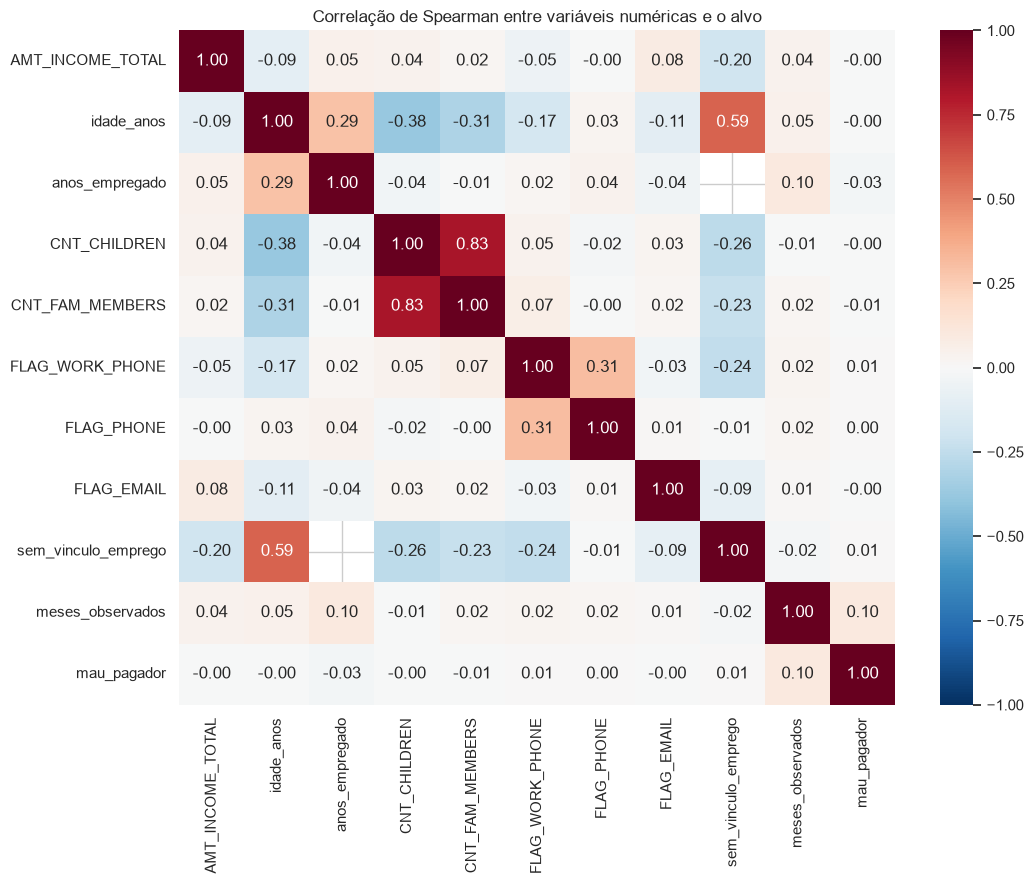

meses_observados       0.0968
anos_empregado        -0.0274
CNT_FAM_MEMBERS       -0.0076
FLAG_WORK_PHONE        0.0056
sem_vinculo_emprego    0.0053
FLAG_EMAIL            -0.0024
idade_anos            -0.0020
CNT_CHILDREN          -0.0017
FLAG_PHONE             0.0016
AMT_INCOME_TOTAL      -0.0014
Name: mau_pagador, dtype: float64

In [10]:
from src.preprocessing import build_target

alvo = build_target(credit)
base = vis.merge(alvo, on="ID", how="inner")
base["meses_observados"] = base["ID"].map(meses_por_cliente)
base["sem_vinculo_emprego"] = (base["DAYS_EMPLOYED"] == config.DIAS_EMPREGO_SENTINELA).astype(int)
print("Clientes presentes nas duas tabelas:", len(base))

numericas = ["AMT_INCOME_TOTAL", "idade_anos", "anos_empregado", "CNT_CHILDREN", "CNT_FAM_MEMBERS",
             "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL", "sem_vinculo_emprego",
             "meses_observados", config.TARGET]
corr = base[numericas].corr(method="spearman")

fig, eixo = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=eixo)
eixo.set_title("Correlação de Spearman entre variáveis numéricas e o alvo")
plt.tight_layout()
plt.savefig(config.FIGURES / "01_correlacoes.png", dpi=120)
plt.show()

corr[config.TARGET].drop(config.TARGET).sort_values(key=abs, ascending=False)

**Interpretação:**

- **Nenhuma variável cadastral numérica tem correlação relevante com o alvo:** todas ficam abaixo
  de 0,03 em módulo. Isso não quer dizer que elas sejam inúteis, porque a correlação de Spearman só
  mede relações monotônicas, uma variável por vez. Mas indica que **nenhum atributo sozinho separa
  bons de maus pagadores**, e é isso que justifica usar modelos que combinam várias variáveis.
- **A maior correlação com o alvo é a de `meses_observados` (0,10):** quanto mais tempo de
  histórico, maior a chance de o cliente ter tido algum mês ruim.
- **Entre as próprias variáveis:**
  - `CNT_CHILDREN` e `CNT_FAM_MEMBERS` (0,83) são quase redundantes, já que a família inclui os
    filhos.
  - `sem_vinculo_emprego` acompanha a idade (0,59), porque são os aposentados.
  - `FLAG_WORK_PHONE` e `FLAG_PHONE` têm correlação moderada (0,31).

As células vazias entre `anos_empregado` e `sem_vinculo_emprego` são esperadas: quem não tem
vínculo não tem tempo de emprego.

## 4. Outliers

Os outliers são procurados com a regra do IQR (valores acima de Q3 + 1,5·IQR) e comparados com o
código sentinela de `DAYS_EMPLOYED`.

,outliers_iqr,pct,max
AMT_INCOME_TOTAL,"19,106.0000",4.3600,"6,750,000.0000"
CNT_CHILDREN,"6,074.0000",1.3900,19.0000
CNT_FAM_MEMBERS,"5,689.0000",1.3000,20.0000
idade_anos,0.0000,0.0000,68.9966
anos_empregado,"20,102.0000",5.5300,47.9973


DAYS_EMPLOYED = 365243: 75324 linhas (17.2%)
Tipo de renda nessas linhas: {'Pensioner': 75324}
OCCUPATION_TYPE nulo nessas linhas: 100.0%


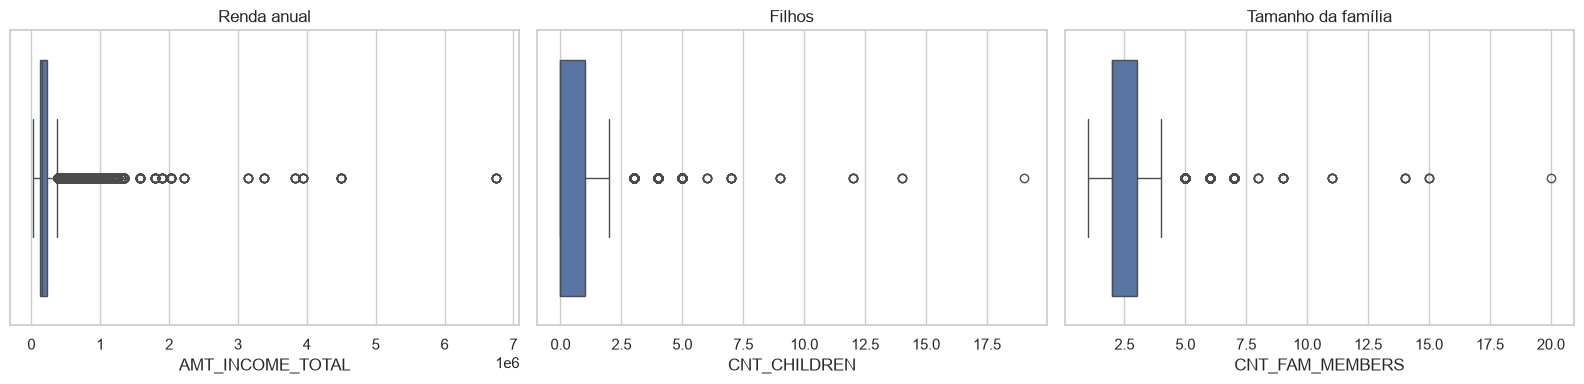

In [11]:
def fora_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    return (serie > q3 + 1.5 * (q3 - q1)) | (serie < q1 - 1.5 * (q3 - q1))

resumo = pd.DataFrame({
    col: {"outliers_iqr": int(fora_iqr(vis[col].dropna()).sum()),
          "pct": round(fora_iqr(vis[col].dropna()).mean() * 100, 2),
          "max": vis[col].max()}
    for col in ["AMT_INCOME_TOTAL", "CNT_CHILDREN", "CNT_FAM_MEMBERS", "idade_anos", "anos_empregado"]
}).T
display(resumo)

sentinela = vis["DAYS_EMPLOYED"] == config.DIAS_EMPREGO_SENTINELA
print(f"DAYS_EMPLOYED = 365243: {sentinela.sum()} linhas ({sentinela.mean():.1%})")
print("Tipo de renda nessas linhas:", vis.loc[sentinela, "NAME_INCOME_TYPE"].value_counts().to_dict())
print("OCCUPATION_TYPE nulo nessas linhas:", f"{vis.loc[sentinela, 'OCCUPATION_TYPE'].isna().mean():.1%}")

fig, eixos = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(x=vis["AMT_INCOME_TOTAL"], ax=eixos[0]).set_title("Renda anual")
sns.boxplot(x=vis["CNT_CHILDREN"], ax=eixos[1]).set_title("Filhos")
sns.boxplot(x=vis["CNT_FAM_MEMBERS"], ax=eixos[2]).set_title("Tamanho da família")
plt.tight_layout()
plt.savefig(config.FIGURES / "01_outliers.png", dpi=120)
plt.show()

**Interpretação e decisão:**

- **`DAYS_EMPLOYED = 365243`** aparece em 75.324 linhas (17,2%), **todas de aposentados**
  (`Pensioner`), e todas elas também estão sem ocupação informada. Não é um erro aleatório: é um
  código para "sem vínculo empregatício". Se usado como número, o modelo leria 1.000 anos de
  emprego. **Decisão:** criar a flag `sem_vinculo_emprego` e deixar o tempo de emprego vazio nesses
  casos. O vazio é preenchido pela mediana dentro do Pipeline, com base só no treino.
- **Renda:** 4,36% dos valores estão acima do limite do IQR, com máximo de 6,75 milhões. **Decisão:
  manter.** Rendas altas são plausíveis, e remover essas linhas descartaria justamente clientes de
  alta renda. Os modelos de árvore não são afetados por valores extremos, e na Regressão Logística
  o efeito é atenuado pela padronização.
- **Filhos e família:** 1,39% e 1,30% acima do IQR, com máximos de 19 e 20. **Decisão: manter.**
  São raros e possíveis, e não há evidência de erro de digitação.
- **Tempo de emprego:** 5,53% acima do IQR, uma cauda longa natural (carreiras longas). **Decisão:
  manter.**

## 5. Balanceamento de classes

,clientes,pct
mau_pagador,,
0,35841,98.3100
1,616,1.6900


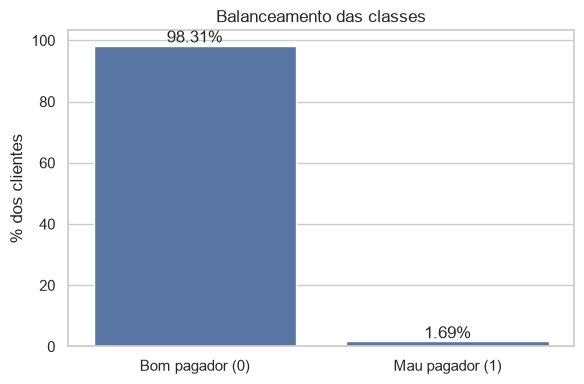

In [12]:
contagem = base[config.TARGET].value_counts().sort_index()
proporcao = base[config.TARGET].value_counts(normalize=True).sort_index()
display(pd.DataFrame({"clientes": contagem, "pct": (proporcao * 100).round(2)},
                     index=pd.Index([0, 1], name="mau_pagador")))

fig, eixo = plt.subplots(figsize=(6, 4))
sns.barplot(x=["Bom pagador (0)", "Mau pagador (1)"], y=proporcao.values * 100, ax=eixo, color="C0")
for i, v in enumerate(proporcao.values * 100):
    eixo.text(i, v + 1, f"{v:.2f}%", ha="center")
eixo.set_ylabel("% dos clientes")
eixo.set_title("Balanceamento das classes")
plt.tight_layout()
plt.savefig(config.FIGURES / "01_balanceamento.png", dpi=120)
plt.show()

**Interpretação:** entre os 36.457 clientes presentes nas duas tabelas, **35.841 (98,31%) são bons
pagadores e só 616 (1,69%) são maus pagadores**. O desbalanceamento é severo, e isso tem três
consequências diretas:

1. **Acurácia não serve como métrica.** Um "modelo" que diz sempre "bom pagador" acerta 98,31% e
   não identifica ninguém.
2. **As métricas passam a ser recall, precisão, F1 e ROC-AUC**, que enxergam a classe rara.
3. **O treino precisa compensar o desequilíbrio** (pesos de classe), e o split precisa ser
   estratificado, para que treino e teste tenham a mesma proporção de maus pagadores.

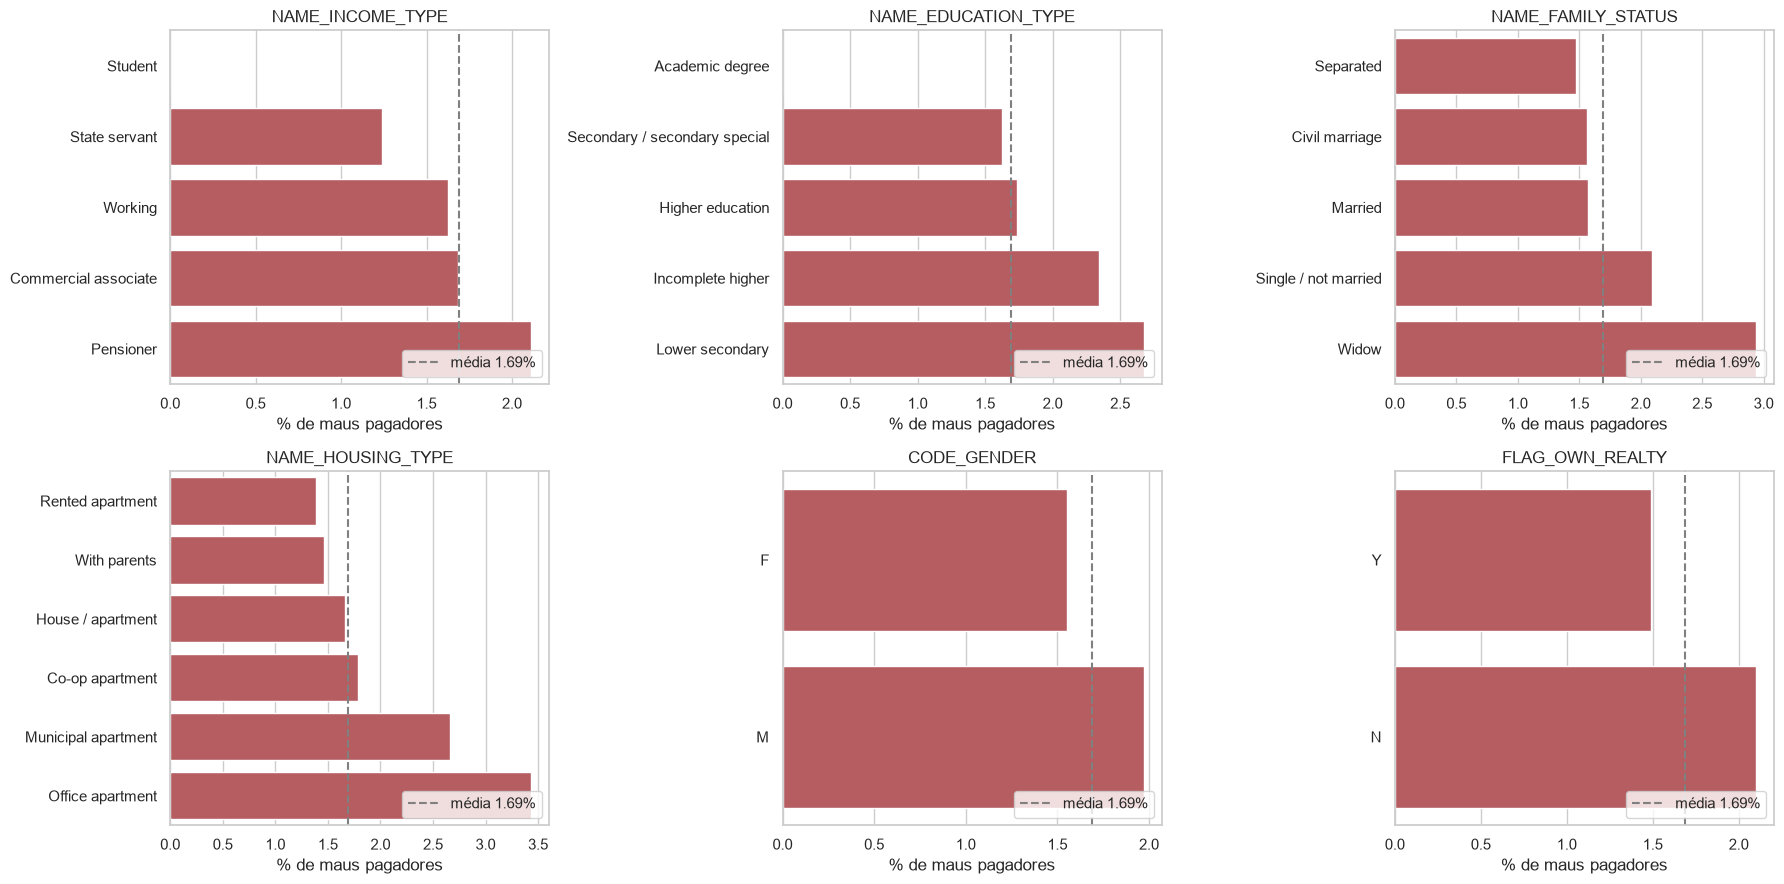

Taxa de mau pagador por faixa de meses de histórico:
meses_observados
(0.999, 8.0]   0.3600
(8.0, 14.0]    1.0600
(14.0, 22.0]   1.2300
(22.0, 35.0]   1.7100
(35.0, 61.0]   4.3000


In [13]:
taxa_geral = base[config.TARGET].mean()
fig, eixos = plt.subplots(2, 3, figsize=(18, 9))
for eixo, col in zip(eixos.flat, ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS",
                                  "NAME_HOUSING_TYPE", "CODE_GENDER", "FLAG_OWN_REALTY"]):
    taxa = base.groupby(col)[config.TARGET].agg(["mean", "size"]).sort_values("mean")
    sns.barplot(x=taxa["mean"] * 100, y=taxa.index, ax=eixo, color="C3")
    eixo.axvline(taxa_geral * 100, color="gray", linestyle="--", label=f"média {taxa_geral:.2%}")
    eixo.set_title(col)
    eixo.set_xlabel("% de maus pagadores")
    eixo.set_ylabel("")
    eixo.legend(loc="lower right")
plt.tight_layout()
plt.savefig(config.FIGURES / "01_taxa_mau_pagador_por_categoria.png", dpi=120)
plt.show()

faixas = pd.qcut(base["meses_observados"], 5)
print("Taxa de mau pagador por faixa de meses de histórico:")
print((base.groupby(faixas, observed=True)[config.TARGET].mean() * 100).round(2).to_string())

**Interpretação:** a taxa média de maus pagadores é 1,69%, e as diferenças entre categorias são
pequenas em valor absoluto, mas consistentes:

- **Tipo de renda:** aposentados 2,11% contra servidores públicos 1,24%.
- **Estado civil:** viúvos 2,94% e solteiros 2,09%, contra 1,57% dos casados.
- **Moradia:** apartamento funcional 3,44% e municipal 2,66% (grupos pequenos, de 262 e 1.128
  clientes), contra 1,66% de quem tem casa ou apartamento próprio.
- **Gênero e patrimônio:** homens 1,97% contra mulheres 1,55%; quem não tem imóvel 2,10% contra
  1,49%.

O padrão mais forte, porém, é o do **tempo de histórico**: a taxa sobe de 0,36% entre quem tem até
8 meses observados para **4,30% entre quem tem de 36 a 61 meses**. Quanto mais meses o cliente é
observado, mais chances ele tem de registrar um atraso. Esse efeito de "tempo de exposição" é
central na interpretação do modelo (notebook 04).

## 6. Síntese da EDA

1. **O evento que queremos prever é raro:** 1,69% de maus pagadores. Isso define as métricas
   (recall, precisão, F1, ROC-AUC) e o tratamento com pesos de classe.
2. **A base tem armadilhas que precisam de tratamento explícito:**
   - `DAYS_EMPLOYED = 365243` é um código para aposentados sem vínculo;
   - a ocupação está vazia em 30,6% dos casos, concentrada em aposentados;
   - há 47 IDs duplicados com dados divergentes;
   - no sentido inverso, a mesma pessoa aparece com vários IDs (90.085 perfis para 438.510 IDs),
     o que obriga a separar treino e teste por pessoa;
   - `FLAG_MOBIL` é constante.
3. **Nenhum atributo cadastral sozinho separa bons de maus pagadores:** as correlações com o alvo
   ficam abaixo de 0,03. O sinal, se existir, está na combinação de variáveis, o que justifica
   modelos multivariados e não lineares.
4. **As diferenças por perfil existem, mas são sutis.** O fator mais forte é o tempo de histórico
   observado, que é uma medida de exposição ao risco, não necessariamente de perfil.

**Narrativa para a apresentação:** *"Mau pagador é raro e não tem um perfil óbvio. Nenhuma
característica isolada denuncia o risco, então é preciso um modelo que combine várias
características. E é preciso medir esse modelo pela capacidade de encontrar os poucos casos de
risco, não pela taxa de acerto geral."*